In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import thư viện

In [ ]:
import warnings
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

import re
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemm = WordNetLemmatizer()

warnings.filterwarnings("ignore")
import plotly.io as pio


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

# Load và kiểm tra data

In [61]:
data = pd.read_csv("/content/drive/MyDrive/RNN/Clothing-Review.csv")
print(data.head(7))
data = data[data['Class Name'].isnull() == False] # Xóa các dòng có tên sản phẩm để trống

   Clothing ID  Age                    Title  \
0          767   33                      NaN   
1         1080   34                      NaN   
2         1077   60  Some major design flaws   
3         1049   50         My favorite buy!   
4          847   47         Flattering shirt   
5         1080   49  Not for the very petite   
6          858   39     Cagrcoal shimmer fun   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   
5  I love tracy reese dresses, but this one is no...       2                0   
6  I aded this in my basket at hte last mintue t

In [62]:
print(f'Số dòng dữ liệu: {data.shape[0]}\nSố cột dữ liệu: {data.shape[1]}')
print("Các cột: ")
for col in data.columns:
  print(f'{col}')

Số dòng dữ liệu: 23472
Số cột dữ liệu: 10
Các cột: 
Clothing ID
Age
Title
Review Text
Rating
Recommended IND
Positive Feedback Count
Division Name
Department Name
Class Name


In [63]:
print("Thống kê mô tả các dữ liệu định lượng:")
print(data[['Age', 'Rating', 'Positive Feedback Count']].describe()) # Thống kê mô tả

Thống kê mô tả các dữ liệu định lượng:
                Age        Rating  Positive Feedback Count
count  23472.000000  23472.000000             23472.000000
mean      43.200707      4.195552                 2.537151
std       12.280913      1.110188                 5.703597
min       18.000000      1.000000                 0.000000
25%       34.000000      4.000000                 0.000000
50%       41.000000      5.000000                 1.000000
75%       52.000000      5.000000                 3.000000
max       99.000000      5.000000               122.000000


In [64]:
# Danh sách sản phẩm kèm số lượng
print(data['Class Name'].value_counts())

# Thống kê tổng tỷ lệ % khuyên dùng sản phẩm
print(f"{round(data['Recommended IND'].value_counts(normalize=True)*100,2)}") # 1: Có, 0: Không

Class Name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
Casual bottoms       2
Chemises             1
Name: count, dtype: int64
Recommended IND
1    82.23
0    17.77
Name: proportion, dtype: float64


# EDA

In [65]:
print("Nhập sản phẩm muốn thống kê theo số thứ tự: ")
print("0. Tất cả sản phẩm")
for i, value in enumerate(data['Class Name'].value_counts().index):
	print(f"{i+1}. {value}")
try:
  choice = int(input('Nhập số: '))
  if choice < 0 or choice > len(data['Class Name'].value_counts()):
    print(f"Vui lòng nhập số từ 0 đến {len(data['Class Name'].value_counts())}")
  elif choice == 0:
    pass
  else:
    product = data['Class Name'].value_counts().index[choice-1]
except ValueError as e:
  print(f"Vui lòng nhập đúng định dạng")

Nhập sản phẩm muốn thống kê theo số thứ tự: 
0. Tất cả sản phẩm
1. Dresses
2. Knits
3. Blouses
4. Sweaters
5. Pants
6. Jeans
7. Fine gauge
8. Skirts
9. Jackets
10. Lounge
11. Swim
12. Outerwear
13. Shorts
14. Sleep
15. Legwear
16. Intimates
17. Layering
18. Trend
19. Casual bottoms
20. Chemises
Nhập số: 6


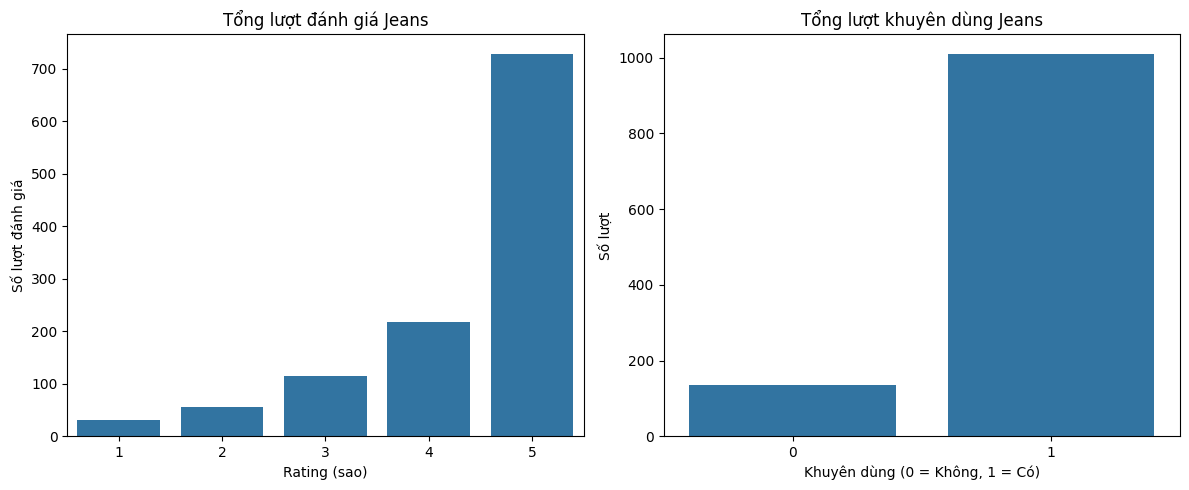

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột thể hiện tổng lượt đánh giá sản phẩm
if 0 < choice < len(data['Class Name'].value_counts()):
  data_plot = data[data['Class Name'] == product]
elif choice == 0:
  data_plot = data
  product = 'Tất cả sản phẩm'

sns.countplot(data = data_plot, x='Rating', ax=axes[0])
axes[0].set_title(f'Tổng lượt đánh giá {product}')
axes[0].set_xlabel('Rating (sao)')
axes[0].set_ylabel('Số lượt đánh giá')



# Biểu đồ cột thể hiện tổng lượt khuyên dùng sản phẩm
sns.countplot(data = data_plot, x="Recommended IND", ax=axes[1])
axes[1].set_title(f'Tổng lượt khuyên dùng {product}')
axes[1].set_xlabel('Khuyên dùng (0 = Không, 1 = Có)')
axes[1].set_ylabel('Số lượt')

# Hiển thị
plt.tight_layout()
plt.show()

In [68]:
import plotly.io as pio

pio.templates["transparent"] = pio.templates["simple_white"]

pio.templates["transparent"].layout.paper_bgcolor = 'rgba(0,0,0,0)'
pio.templates["transparent"].layout.plot_bgcolor  = 'rgba(0,0,0,0)'

pio.templates.default = "transparent"

In [117]:
# Biểu đồ thống kê lượng khuyên dùng/ không khuyên dùng theo độ tuổi
fig = px.histogram(data, marginal='box',
				x="Age", title="Thống kê lượt khuyên dùng theo độ tuổi",
				color="Recommended IND",
				nbins=65-18,
				color_discrete_sequence=['aqua', 'violet'])
fig.update_layout(
		 bargap=0.2,
		 font=dict(
        color='white'
    ))
fig.update_traces(marker=dict(
        line=dict(
            color='black',
            width=1
        )))


In [128]:
#Biểu đồ thống kê lượt đánh giá theo độ tuổi
fig = px.histogram(data,
				x="Age",
				marginal='box',
				title="Thống kê lượt đánh giá theo độ tuổi",
				color="Rating",
				nbins=65-18,
				color_discrete_sequence
				=['aliceblue', 'skyblue', 'turquoise', 'aqua', 'darkcyan'])
fig.update_layout(
		 font=dict(
				color='white'
		 ),
	 	bargap=0.2
	)
fig.update_traces(
		 marker=dict(
        line=dict(
            color='black',
            width=1
			)))

# Chuẩn hóa dữ liệu

In [129]:
def filter_score(rating):
	return int(rating > 3)

features = ['Class Name', 'Title', 'Review Text']	# Chọn các features cần học
# Lưu ý feature phục vụ cho việc học ngôn ngữ chứ không để tối ưu hóa doanh thu

X = data[features]
y = data['Rating']
y = y.apply(filter_score)

In [130]:
def toLower(data):
	if isinstance(data, float):
		return '<UNK>'
	else:
		return data.lower()

stop_words = stopwords.words("english")

def remove_stopwords(text):
	no_stop = []
	for word in text.split(' '):
		if word not in stop_words:
			no_stop.append(word)
	return " ".join(no_stop)

def remove_punctuation_func(text):
	return re.sub(r'[^a-zA-Z0-9]', ' ', text)

# Chuyển chữ thường
X['Title'] = X['Title'].apply(toLower)
X['Review Text'] = X['Review Text'].apply(toLower)

# Xóa dấu câu (dấu chấm, phẩy, !, ?, ...)
X['Title'] = X['Title'].apply(remove_punctuation_func)
X['Review Text'] = X['Review Text'].apply(remove_punctuation_func)

# Xóa từ dừng (stopwords như: "the", "is", "and", ...)
X['Title'] = X['Title'].apply(remove_stopwords)
X['Review Text'] = X['Review Text'].apply(remove_stopwords)

# Lemmatization: chuyển từ về dạng gốc (ví dụ "running" → "run")
X['Title'] = X['Title'].apply(lambda x: ' '.join([lemm.lemmatize(word) for word in x.split()]))
X['Review Text'] = X['Review Text'].apply(lambda x: ' '.join([lemm.lemmatize(word) for word in x.split()]))

# Gộp lại thành 1 cột văn bản duy nhất để đưa vào mô hình
X['Text'] = X['Title'] + " " + X['Review Text'] + " " + X['Class Name']

# Modeling

In [207]:
# Chia tập train test
X_train, X_test, y_train, y_test = train_test_split(X['Text'], y, test_size=0.25, random_state=42)

In [208]:
# Giữ lại 10.000 từ phổ biến nhất, <OOV> (Out Of Vocabulary) => Các từ còn lại gom chung là từ lạ
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [209]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [210]:
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

train_pad = pad_sequences(train_seq,
						maxlen=40,		# độ dài mỗi câu
						truncating="post",	# thiếu thì thêm 0 ở cuối
						padding="post"	# dài quá thì cắt từ cuối
						)
test_pad = pad_sequences(test_seq,
						maxlen=40,
						truncating="post",
						padding="post"
						)

In [211]:
# Thiết kế layer
model_rnn= keras.models.Sequential()
model_rnn.add(keras.layers.Embedding(10000, 128))
model_rnn.add(keras.layers.SimpleRNN(64, return_sequences=True))
model_rnn.add(keras.layers.SimpleRNN(64))
model_rnn.add(keras.layers.Dense(128, activation="relu"))
model_rnn.add(keras.layers.Dropout(0.4))
model_rnn.add(keras.layers.Dense(1, activation="sigmoid"))

# Chạy model
model_rnn.compile("rmsprop","binary_crossentropy",metrics=["accuracy"])
history_rnn = model_rnn.fit(train_pad, y_train, epochs=5, validation_split=0.2, class_weight=class_weights)

Epoch 1/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.5377 - loss: 0.7067 - val_accuracy: 0.7952 - val_loss: 0.6135
Epoch 2/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.7767 - loss: 0.5631 - val_accuracy: 0.8020 - val_loss: 0.4669
Epoch 3/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.7935 - loss: 0.5257 - val_accuracy: 0.7913 - val_loss: 0.5620
Epoch 4/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.7875 - loss: 0.5130 - val_accuracy: 0.8503 - val_loss: 0.3889
Epoch 5/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.8062 - loss: 0.4343 - val_accuracy: 0.8600 - val_loss: 0.3516


In [212]:
model_LSTM= keras.models.Sequential()
model_LSTM.add(keras.layers.Embedding(10000, 128))
model_LSTM.add(keras.layers.Bidirectional(
	keras.layers.LSTM(64, return_sequences=True)))
model_LSTM.add(keras.layers.Bidirectional(keras.layers.LSTM(64)))
model_LSTM.add(keras.layers.Dense(128, activation="relu"))
model_LSTM.add(keras.layers.Dropout(0.4))
model_LSTM.add(keras.layers.Dense(1, activation="sigmoid"))

model_LSTM.compile("rmsprop", "binary_crossentropy", metrics=["accuracy"])
history_LSTM = model_rnn.fit(train_pad, y_train, epochs=5, validation_split=0.2, class_weight=class_weights)

Epoch 1/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8592 - loss: 0.3693 - val_accuracy: 0.3772 - val_loss: 0.9171
Epoch 2/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.8619 - loss: 0.3449 - val_accuracy: 0.3732 - val_loss: 0.9539
Epoch 3/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8546 - loss: 0.3400 - val_accuracy: 0.8722 - val_loss: 0.3169
Epoch 4/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8798 - loss: 0.3457 - val_accuracy: 0.8529 - val_loss: 0.4154
Epoch 5/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.8862 - loss: 0.3167 - val_accuracy: 0.8580 - val_loss: 0.4481


In [213]:
model_GRU= keras.models.Sequential()
model_GRU.add(keras.layers.Embedding(10000, 128))
model_GRU.add(keras.layers.Bidirectional(
	keras.layers.GRU(64, return_sequences=True)))
model_GRU.add(keras.layers.Bidirectional(keras.layers.GRU(64)))
model_GRU.add(keras.layers.Dense(128, activation="relu"))
model_GRU.add(keras.layers.Dropout(0.4))
model_GRU.add(keras.layers.Dense(1, activation="sigmoid"))

model_GRU.compile("rmsprop", "binary_crossentropy", metrics=["accuracy"])
history_GRU = model_rnn.fit(train_pad, y_train, epochs=5, validation_split=0.2, class_weight=class_weights)

Epoch 1/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8926 - loss: 0.2840 - val_accuracy: 0.8651 - val_loss: 0.3669
Epoch 2/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8999 - loss: 0.2680 - val_accuracy: 0.8606 - val_loss: 0.5308
Epoch 3/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9069 - loss: 0.2817 - val_accuracy: 0.8248 - val_loss: 0.5952
Epoch 4/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9096 - loss: 0.2853 - val_accuracy: 0.8358 - val_loss: 0.4939
Epoch 5/5
441/441 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9102 - loss: 0.2355 - val_accuracy: 0.7930 - val_loss: 0.7408


In [214]:
rnn_loss, rnn_acc = model_rnn.evaluate(test_pad, y_test)
lstm_loss, lstm_acc = model_LSTM.evaluate(test_pad, y_test)
gru_loss, gru_acc = model_GRU.evaluate(test_pad, y_test)

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8056 - loss: 0.6760
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.5783 - loss: 0.6927
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5103 - loss: 0.6930
RNN Accuracy: 0.7994205951690674
LSTM Accuracy: 0.5802658200263977
GRU Accuracy: 0.5138036608695984


In [215]:
def preprocess_input(text):
    text = text.lower()
    text = remove_punctuation_func(text)
    text = remove_stopwords(text)
    text = " ".join([lemm.lemmatize(w) for w in text.split()])

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=40, padding='post', truncating='post')
    return pad


def predict_review(text, model):
    x = preprocess_input(text)
    prob = model.predict(x)[0][0]

    if prob >= 0.7:
        label = "Recommended 👍"
    elif prob <= 0.3:
        label = "Not recommended 👎"
    else:
        label = "Uncertain 🤔"

    return label, float(prob)


In [216]:
texts = [
        "The dress is absolutely beautiful, the quality is excellent and I really love it.",
        "Perfect fit, great material, and looks exactly like the pictures. Highly recommended!",
        "The dress is nice and looks good, but the size is a little bit off.",
        "I like the design, but the fabric feels a bit cheap.",
        "The dress looks good in photos but the quality is disappointing.",
        "The material is thin and not what I expected.",
        "I hate this dress, it is badly made and not worth the money.",
        "The product arrived damaged and looks nothing like the description.",
        "The dress is beatiful and amazzing, i luv it so much!!!",
        "Very gud dress, fitz perfecly.",
        ]

models = [model_rnn, model_LSTM, model_GRU]
for model in models:
  print(f"*************Model: {model.name}*************")
  for text in texts:
    print(f"{text}: \nPredict: {predict_review(text, model)}")

*************Model: sequential_7*************
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
The dress is absolutely beautiful, the quality is excellent and I really love it.: 
Predict: ('Recommended 👍', 0.959705114364624)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Perfect fit, great material, and looks exactly like the pictures. Highly recommended!: 
Predict: ('Recommended 👍', 0.9790397882461548)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The dress is nice and looks good, but the size is a little bit off.: 
Predict: ('Not recommended 👎', 0.21795296669006348)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
I like the design, but the fabric feels a bit cheap.: 
Predict: ('Not recommended 👎', 0.03754844516515732)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
The dress looks good in photos but the quality is disappointing.: 
Predict: ('Not recommended 👎', 0.03499643877148628)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The material is thin and not what I expected.: 
Predict: ('Not recommended 👎', 0.033132404088974)
1/1 ━━━━━━━━━━

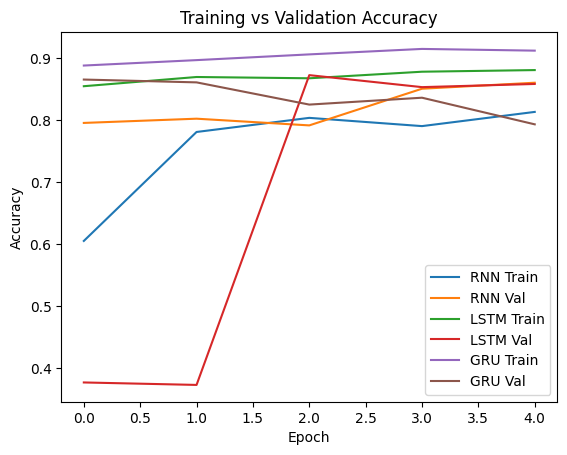

In [217]:
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')
plt.plot(history_LSTM.history['accuracy'], label='LSTM Train')
plt.plot(history_LSTM.history['val_accuracy'], label='LSTM Val')
plt.plot(history_GRU.history['accuracy'], label='GRU Train')
plt.plot(history_GRU.history['val_accuracy'], label='GRU Val')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()